<a href="https://colab.research.google.com/github/Rachel-Cellulose/Uae_Cancer_Analysis/blob/main/EDA0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded = files.upload()


Saving Cancer.csv to Cancer.csv


In [4]:
import pandas as pd
import io


filename = 'Cancer.csv'
df = pd.read_csv(io.BytesIO(uploaded[filename]))

df.head()



,Patient_ID,Age,Gender,Nationality,Emirate,Diagnosis_Date,Cancer_Type,Cancer_Stage,Treatment_Type,Treatment_Start_Date,Hospital,Primary_Physician,Outcome,Death_Date,Cause_of_Death,Smoking_Status,Comorbidities,Ethnicity,Weight,Height
0,PAT000001,69,Female,Emirati,Umm Al Quwain,11/30/2020,Liver,II,Radiation,12/4/2020,Sheikh Khalifa Hospital,Dr. VO41,Recovered,NaN,NaN,Non-Smoker,NaN,European,61,157
1,PAT000002,32,Male,Emirati,Umm Al Quwain,10/10/2015,Leukemia,III,Surgery,11/5/2015,Dubai Hospital,Dr. SM31,Recovered,NaN,NaN,Smoker,NaN,South Asian,80,175
2,PAT000003,89,Male,Emirati,Abu Dhabi,2/13/2018,Liver,III,Radiation,8/3/2018,Zayed Military Hospital,Dr. BC7,Under Treatment,NaN,NaN,Non-Smoker,NaN,South Asian,50,175
3,PAT000004,78,Female,Emirati,Abu Dhabi,2/4/2022,Lung,III,Radiation,3/13/2022,Cleveland Clinic Abu Dhabi,Dr. TC14,Recovered,NaN,NaN,Former Smoker,NaN,African,44,155
4,PAT000005,38,Female,Emirati,Fujairah,12/3/2019,Pancreatic,II,Chemotherapy,2/29/2020,Sheikh Khalifa Hospital,Dr. YS37,Recovered,NaN,NaN,Former Smoker,NaN,East Asian,101,160


In [5]:

print("Missing values per column:\n", df.isnull().sum())


df.replace(['N/A', '######', '########', '#########'], pd.NA, inplace=True)


date_cols = ['Treatment_Start_Date', 'Death_Date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')  # handles invalid dates safely


df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')
df['Height'] = pd.to_numeric(df['Height'], errors='coerce')
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')


df.dropna(subset=['Age', 'Cancer_Type', 'Treatment_Type'], inplace=True)


df.reset_index(drop=True, inplace=True)


df.info()




Missing values per column:
 Patient_ID                 0
Age                        0
Gender                     0
Nationality                0
Emirate                    0
Diagnosis_Date             0
Cancer_Type                0
Cancer_Stage               0
Treatment_Type             0
Treatment_Start_Date       0
Hospital                   0
Primary_Physician          0
Outcome                    0
Death_Date              9008
Cause_of_Death          9008
Smoking_Status             0
Comorbidities           4047
Ethnicity                  0
Weight                     0
Height                     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Patient_ID            10000 non-null  object        
 1   Age                   10000 non-null  int64         
 2   Gender                10000 non-nu

In [6]:
df.head(10)


,Patient_ID,Age,Gender,Nationality,Emirate,Diagnosis_Date,Cancer_Type,Cancer_Stage,Treatment_Type,Treatment_Start_Date,Hospital,Primary_Physician,Outcome,Death_Date,Cause_of_Death,Smoking_Status,Comorbidities,Ethnicity,Weight,Height
0,PAT000001,69,Female,Emirati,Umm Al Quwain,11/30/2020,Liver,II,Radiation,2020-12-04,Sheikh Khalifa Hospital,Dr. VO41,Recovered,NaT,NaN,Non-Smoker,NaN,European,61,157
1,PAT000002,32,Male,Emirati,Umm Al Quwain,10/10/2015,Leukemia,III,Surgery,2015-11-05,Dubai Hospital,Dr. SM31,Recovered,NaT,NaN,Smoker,NaN,South Asian,80,175
2,PAT000003,89,Male,Emirati,Abu Dhabi,2/13/2018,Liver,III,Radiation,2018-08-03,Zayed Military Hospital,Dr. BC7,Under Treatment,NaT,NaN,Non-Smoker,NaN,South Asian,50,175
3,PAT000004,78,Female,Emirati,Abu Dhabi,2/4/2022,Lung,III,Radiation,2022-03-13,Cleveland Clinic Abu Dhabi,Dr. TC14,Recovered,NaT,NaN,Former Smoker,NaN,African,44,155
4,PAT000005,38,Female,Emirati,Fujairah,12/3/2019,Pancreatic,II,Chemotherapy,2020-02-29,Sheikh Khalifa Hospital,Dr. YS37,Recovered,NaT,NaN,Former Smoker,NaN,East Asian,101,160
5,PAT000006,41,Female,Emirati,Abu Dhabi,2/10/2015,Breast,I,Surgery,2015-04-21,Dubai Hospital,Dr. ZL30,Recovered,NaT,NaN,Smoker,Hypertension,European,59,176
6,PAT000007,20,Male,Emirati,Ras Al Khaimah,2/27/2023,Ovarian,IV,Chemotherapy,2023-05-15,Sheikh Khalifa Hospital,Dr. AL45,Recovered,NaT,NaN,Non-Smoker,Hypertension,Arab,66,155
7,PAT000008,39,Male,Expatriate,Sharjah,4/5/2018,Breast,I,Surgery,2018-08-10,Sheikh Khalifa Hospital,Dr. IL20,Under Treatment,NaT,NaN,Non-Smoker,NaN,South Asian,27,189
8,PAT000009,70,Female,Emirati,Umm Al Quwain,12/12/2022,Lung,III,Immunotherapy,2023-05-29,Dubai Hospital,Dr. KH33,Deceased,2024-12-22,Cancer,Non-Smoker,NaN,South Asian,60,162
9,PAT000010,19,Female,Emirati,Dubai,5/29/2018,Breast,I,Surgery,2018-07-25,Cleveland Clinic Abu Dhabi,Dr. GX45,Recovered,NaT,NaN,Non-Smoker,NaN,East Asian,73,180


In [7]:
# First, install openpyxl if it's not already installed
!pip install openpyxl

# Save the cleaned DataFrame to an Excel file
df.to_excel("cleaned_data.xlsx", index=False)

# Download it using Colab's files module
from google.colab import files
files.download("cleaned_data.xlsx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
import pandas as pd
df = pd.read_excel("cleaned_data.xlsx")

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look nicer
sns.set(style="whitegrid")

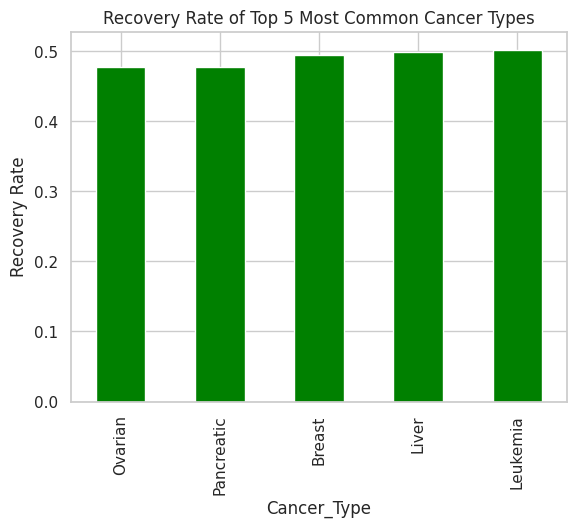

In [17]:
# Get top 5 common types
top5 = df['Cancer_Type'].value_counts().nlargest(5).index

# Filter data to only those top 5
top5_data = df[df['Cancer_Type'].isin(top5)]

# Calculate recovery rate
top5_recovery = top5_data[top5_data['Outcome'] == 'Recovered'].groupby('Cancer_Type').size() / top5_data.groupby('Cancer_Type').size()

# Plot
top5_recovery.sort_values().plot(kind='bar', color='green', title='Recovery Rate of Top 5 Most Common Cancer Types')
plt.ylabel('Recovery Rate')
plt.show()


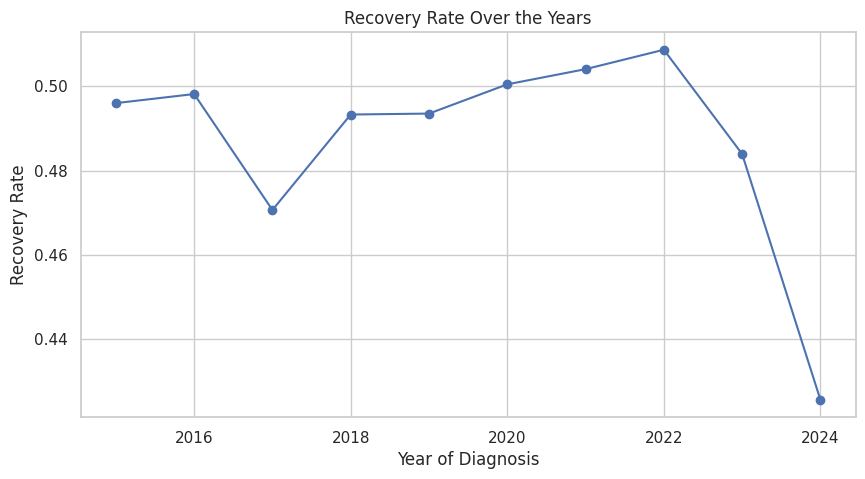

In [18]:
# Add a column for diagnosis year
df['Diagnosis_Year'] = pd.to_datetime(df['Diagnosis_Date'], errors='coerce').dt.year

# Calculate recovery rate per year
recovery_by_year = df[df['Outcome'] == 'Recovered'].groupby('Diagnosis_Year').size() / df.groupby('Diagnosis_Year').size()

# Plot it
recovery_by_year.plot(kind='line', marker='o', title='Recovery Rate Over the Years', figsize=(10,5))
plt.ylabel('Recovery Rate')
plt.xlabel('Year of Diagnosis')
plt.grid(True)
plt.show()


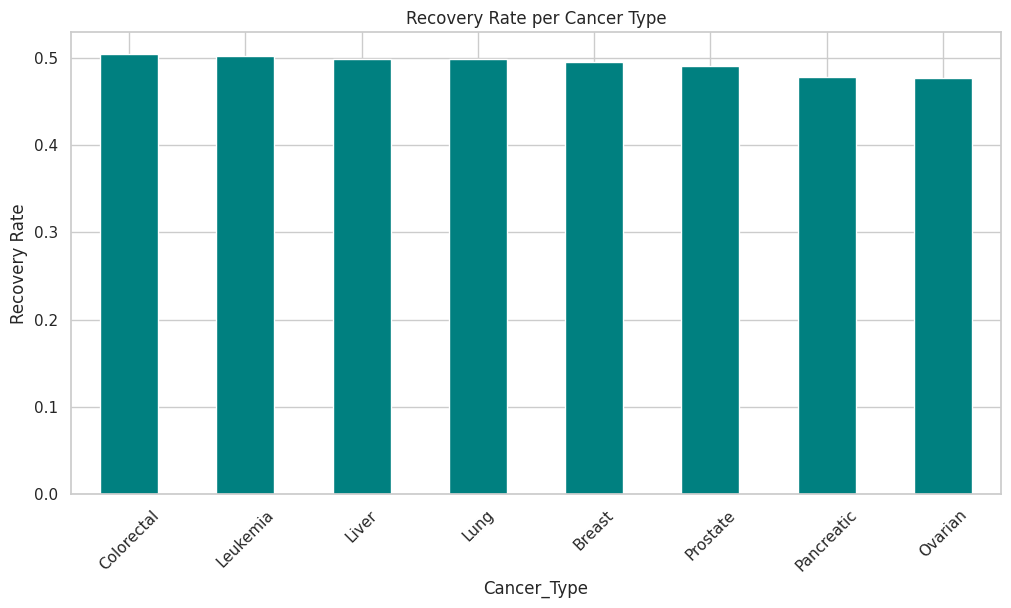

In [19]:
recovery_by_type = df[df['Outcome'] == 'Recovered'].groupby('Cancer_Type').size() / df.groupby('Cancer_Type').size()

recovery_by_type.sort_values(ascending=False).plot(kind='bar', figsize=(12,6), title='Recovery Rate per Cancer Type', color='teal')
plt.ylabel('Recovery Rate')
plt.xticks(rotation=45)
plt.show()


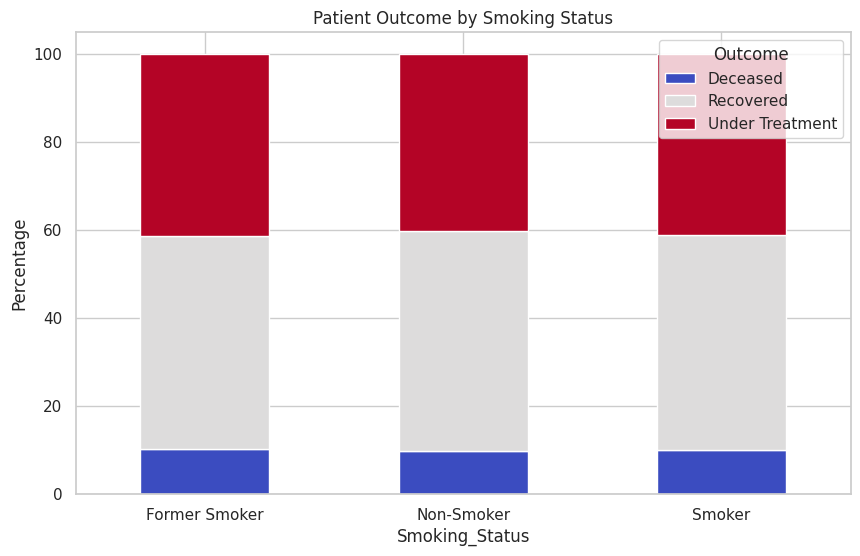

In [20]:
smoking_outcomes = pd.crosstab(df['Smoking_Status'], df['Outcome'], normalize='index') * 100

smoking_outcomes.plot(kind='bar', stacked=True, figsize=(10,6), title='Patient Outcome by Smoking Status', colormap='coolwarm')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()


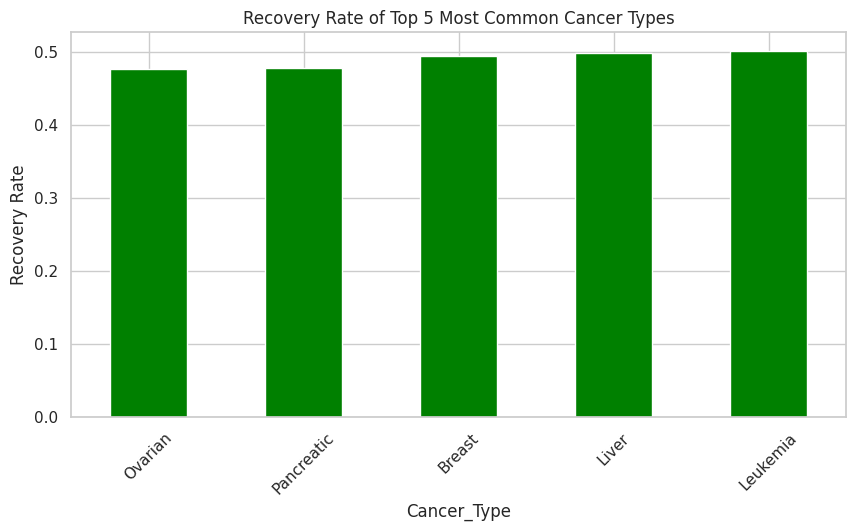

In [21]:
top5 = df['Cancer_Type'].value_counts().nlargest(5).index
top5_data = df[df['Cancer_Type'].isin(top5)]

top5_recovery = top5_data[top5_data['Outcome'] == 'Recovered'].groupby('Cancer_Type').size() / top5_data.groupby('Cancer_Type').size()

top5_recovery.sort_values().plot(kind='bar', color='green', title='Recovery Rate of Top 5 Most Common Cancer Types', figsize=(10,5))
plt.ylabel('Recovery Rate')
plt.xticks(rotation=45)
plt.show()
